### import dependencies

In [1]:
import numpy as np
from libpysal.weights import lat2W, Kernel
from numpy.linalg import inv
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.metrics import mean_squared_error, r2_score
from spglm.iwls import _compute_betas_gwr, iwls
from spglm.family import Gaussian
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process import GaussianProcessRegressor
from statsmodels.api import OLS
from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW
import libpysal as ps  # Ensure PySAL is installed
import geopandas as gpd
from shapely.geometry import Point, Polygon
import pandas as pd
from scipy.stats import pearsonr

from numpy.linalg import inv

import warnings
warnings.filterwarnings('ignore')

### Define helper functions

In [2]:
## Define autocorrelation function. 
def draw_map(N, lamb, W, random_state=None):
    """
    N    = number of areal units
    lamb = spatial autocorrelation parameter
    W    = spatial weights matrix
    random_state = optional seed for reproducibility
    """
    if random_state is not None:
        np.random.seed(random_state)

    W.transform = "r"
    e = np.random.random((N, 1))
    u = inv(np.eye(N) - lamb * W.full()[0])
    u = np.dot(u, e)
    u = (u - u.mean()) / np.std(u)
    return u

# Function to create tract polygons over the area
def create_tracts(xmin, xmax, ymin, ymax, x_step, y_step):
    polys = []
    ids = []
    id_counter = 0
    for x0 in np.arange(xmin, xmax, x_step):
        for y0 in np.arange(ymin, ymax, y_step):
            x1 = x0 + x_step
            y1 = y0 + y_step
            poly = Polygon([(x0, y0), (x1, y0), (x1, y1), (x0, y1)])
            polys.append(poly)
            ids.append(id_counter)
            id_counter += 1
    gdf = gpd.GeoDataFrame({'tract_id': ids, 'geometry': polys})
    return gdf

# Define grid parameters and create tracts
xmin, xmax = 0, 600
ymin, ymax = 0, 600

# This is the step where I choose the size of the tracts
x_step, y_step = 25, 25 # Creates a 48x48 grid, resulting in 2304 tracts
tracts_gdf24 = create_tracts(xmin, xmax, ymin, ymax, x_step, y_step)

orig_tracts_gdf24 = create_tracts(xmin, xmax, ymin, ymax, x_step, y_step) # this is important as its used in 16x16 visualiation

#### Simulate X2 and X3 

- X2 and X3 simulated at point supports S2 and S3 represent covariates at a different support from the dependent variable (y)

In [3]:
def simulate_clustered_S2(num_points, background_points, num_clusters, grid_gdf, cluster_std=50, random_state=None):
   
    if random_state is not None:
        np.random.seed(random_state)

    x_range = (grid_gdf.total_bounds[0], grid_gdf.total_bounds[2])
    y_range = (grid_gdf.total_bounds[1], grid_gdf.total_bounds[3])

    centers = np.random.uniform(low=x_range[0], high=x_range[1], size=(num_clusters, 2))
    clustered_locations, _ = make_blobs(n_samples=num_points, centers=centers, cluster_std=cluster_std)

    # Clip points to stay within the study area
    clustered_locations[:, 0] = np.clip(clustered_locations[:, 0], x_range[0], x_range[1])
    clustered_locations[:, 1] = np.clip(clustered_locations[:, 1], y_range[0], y_range[1])

    background_locations = np.random.uniform(low=[x_range[0], y_range[0]],
                                             high=[x_range[1], y_range[1]],
                                             size=(background_points, 2))

    # Step 4: Combine All Points
    all_locations = np.vstack((clustered_locations, background_locations))

    ## Generate data
    Nlat = 24
    N = Nlat**2
    D = 2
    M = 3
    W = lat2W(Nlat, Nlat, rook=True)

    rawX1 = draw_map(N, .70, W).flatten()

    # newX = (rawX1-rawX1.min()) / (rawX1.max()-rawX1.min()) #* (7000 - 250) + 250 
    
    x = all_locations[:, 0]
    y = all_locations[:, 1]
    S2 = []
    cell_size = 600 / Nlat  # 12.5 in this case
    S2 = []
    for i in range(len(all_locations)):
        u = min(int(np.floor(x[i] / cell_size)), Nlat - 1)
        v = min(int(np.floor(y[i] / cell_size)), Nlat - 1)
        S2.append(rawX1[u * Nlat + v])

    return np.array(S2), np.array(all_locations)

# Run Simulation with Ensured Coverage
S2, loc2  = simulate_clustered_S2(num_points=2000, background_points=1600, num_clusters=15, grid_gdf=tracts_gdf24,
                                 cluster_std=25, random_state=27)

S1 = tracts_gdf24
loc1 = np.array([[point.x, point.y] for point in S1.geometry.centroid])

agg_df = tracts_gdf24.copy()

In [4]:
def simulate_clustered_S3(num_points, background_points, num_clusters, grid_gdf, cluster_std=50, random_state=None):
   
    if random_state is not None:
        np.random.seed(random_state)

    x_range = (grid_gdf.total_bounds[0], grid_gdf.total_bounds[2])
    y_range = (grid_gdf.total_bounds[1], grid_gdf.total_bounds[3])

    centers = np.random.uniform(low=x_range[0], high=x_range[1], size=(num_clusters, 2))
    clustered_locations, _ = make_blobs(n_samples=num_points, centers=centers, cluster_std=cluster_std)

    # Clip points to stay within the study area
    clustered_locations[:, 0] = np.clip(clustered_locations[:, 0], x_range[0], x_range[1])
    clustered_locations[:, 1] = np.clip(clustered_locations[:, 1], y_range[0], y_range[1])

    background_locations = np.random.uniform(low=[x_range[0], y_range[0]],
                                             high=[x_range[1], y_range[1]],
                                             size=(background_points, 2))

    # Step 4: Combine All Points
    all_locations = np.vstack((clustered_locations, background_locations))

    ## Generate data
    Nlat = 24
    N = Nlat**2
    D = 2
    M = 3
    W = lat2W(Nlat, Nlat, rook=True)

    rawX1 = draw_map(N, .98, W).flatten()

    # newX = (rawX1-rawX1.min()) / (rawX1.max()-rawX1.min()) #* (7000 - 250) + 250 
    
    x = all_locations[:, 0]
    y = all_locations[:, 1]
    S3 = []
    cell_size = 600 / Nlat  # 12.5 in this case
    S3 = []
    for i in range(len(all_locations)):
        u = min(int(np.floor(x[i] / cell_size)), Nlat - 1)
        v = min(int(np.floor(y[i] / cell_size)), Nlat - 1)
        S3.append(rawX1[u * Nlat + v])

    return np.array(S3), np.array(all_locations)

# Run Simulation with Ensured Coverage
S3, loc3  = simulate_clustered_S3(num_points=1900, background_points=1016, num_clusters=20, grid_gdf=tracts_gdf24,
                                 cluster_std=25, random_state=42)

-- Viusalize spatial distribution of X2 and X3 @ support S2 and S3

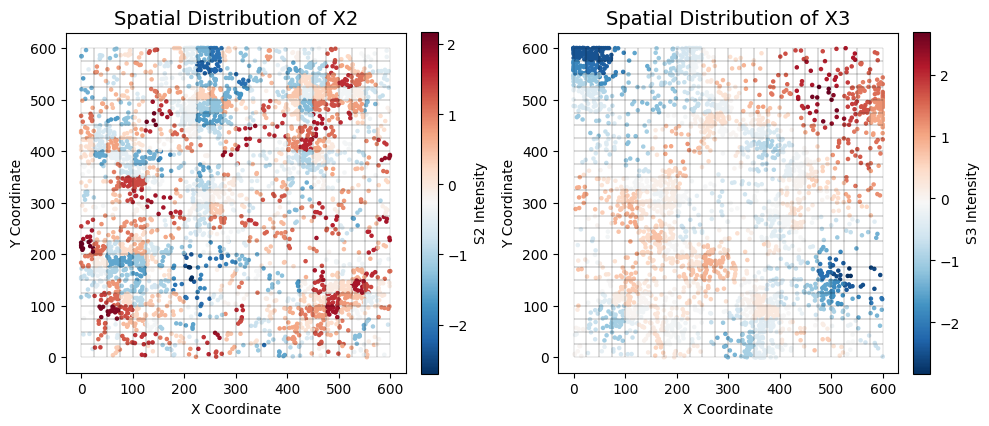

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))  # 1 row, 2 columns

# Shared colormap
cmap = plt.cm.RdBu_r

# Plot 1: X2
tracts_gdf24.boundary.plot(ax=axes[0], edgecolor="black", linewidth=0.1)
sc1 = axes[0].scatter(loc2[:, 0], loc2[:, 1], c=S2, cmap=cmap, edgecolor="face", s=5)
cbar1 = fig.colorbar(sc1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label("S2 Intensity")
axes[0].set_title("Spatial Distribution of X2", fontsize=14)
axes[0].set_xlabel("X Coordinate")
axes[0].set_ylabel("Y Coordinate")

# Plot 2: X3
tracts_gdf24.boundary.plot(ax=axes[1], edgecolor="black", linewidth=0.1)
sc2 = axes[1].scatter(loc3[:, 0], loc3[:, 1], c=S3, cmap=cmap, edgecolor="face", s=5)
cbar2 = fig.colorbar(sc2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label("S3 Intensity")
axes[1].set_title("Spatial Distribution of X3", fontsize=14)
axes[1].set_xlabel("X Coordinate")
axes[1].set_ylabel("Y Coordinate")

plt.tight_layout()
plt.show()


- Simulate beta surfaces.
  - Two types of beta surfaces were generated over a 24x24 grid.
    1. A constant value of β = 2 was assigned to all grid cells for the uniform beta surface
    2. A spatially autocorrelated beta with ρ = 0.9
  

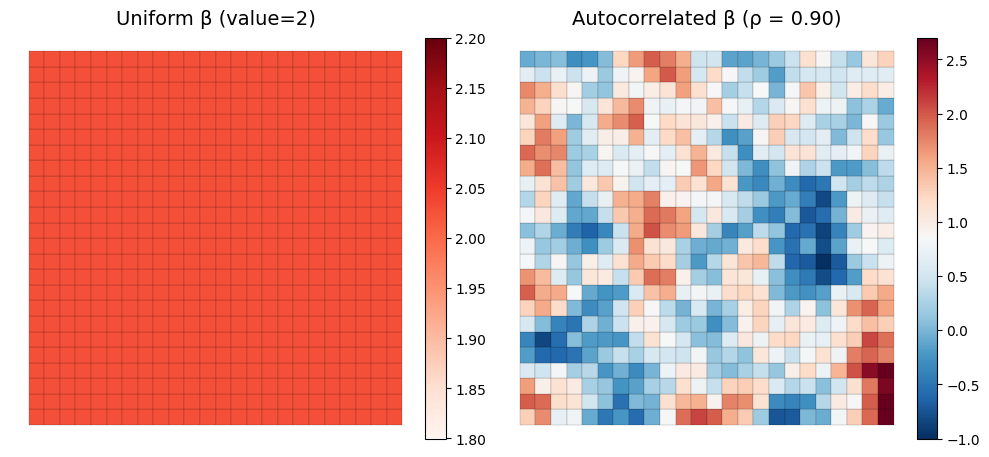

In [6]:
## Generate beta
Nlat = 24
N = Nlat**2

W = lat2W(Nlat, Nlat, rook=True)
p=0.90
np.random.seed(2025)
beta_surface = draw_map(N, 0.90, W)
beta_surface_scaled = 3.7 * (beta_surface - beta_surface.min()) / (beta_surface.max() - beta_surface.min()) - 1

def uniform(Nlat, value=2):
 
    return np.full((Nlat**2, 1), value)

uniform_beta = uniform(24)

tracts_gdf24['uniform_beta'] = uniform_beta
tracts_gdf24['autocorr_beta'] = beta_surface_scaled

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
cmap = plt.cm.RdBu_r
cmap2 = plt.cm.Reds

# Uniform Beta
tracts_gdf24.plot(column="uniform_beta", cmap=cmap2, linewidth=0.1, edgecolor='k',
                  ax=axes[0], vmin=0, vmax=3.5)
axes[0].set_title("Uniform β (value=2)", fontsize=14)
axes[0].axis('off')
sm1 = cm.ScalarMappable(cmap=cmap2, norm=mcolors.Normalize(
    vmin=tracts_gdf24["uniform_beta"].min(), vmax=tracts_gdf24["uniform_beta"].max()))
sm1._A = []
fig.colorbar(sm1, ax=axes[0], orientation="vertical", fraction=0.046, pad=0.01)

# Spatially Autocorrelated Beta
tracts_gdf24.plot(column="autocorr_beta", cmap=cmap, linewidth=0.1, edgecolor='k',
                  ax=axes[1])
axes[1].set_title(f"Autocorrelated β (ρ = {p:.2f})", fontsize=14)
axes[1].axis('off')
sm4 = cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(
    vmin=tracts_gdf24["autocorr_beta"].min(), vmax=tracts_gdf24["autocorr_beta"].max()))
sm4._A = []
fig.colorbar(sm4, ax=axes[1], orientation="vertical", fraction=0.046, pad=0.01)

plt.tight_layout()
plt.show()

### Generating the dependent variable 

- Set k=20 for X2 and k=35 for X3

- add Noise from normal distribution such that e = N(0, 0.05)

In [7]:
k_S2 = 20 
k_S3 = 35 

nbrs_S2 = NearestNeighbors(n_neighbors=k_S2).fit(loc2)
nbrs_S3 = NearestNeighbors(n_neighbors=k_S3).fit(loc3)

smoothed_S2_to_S1 = np.zeros(len(S1))
smoothed_S3_to_S1 = np.zeros(len(S1))

# Loop over each target location in loc1
for i in range(len(S1)):
    # --- S2 smoothing ---
    _, idx2 = nbrs_S2.kneighbors(loc1[i].reshape(1, -1))
    smoothed_S2_to_S1[i] = np.mean(S2[idx2[0]])

    # --- S3 smoothing ---
    _, idx3 = nbrs_S3.kneighbors(loc1[i].reshape(1, -1))
    smoothed_S3_to_S1[i] = np.mean(S3[idx3[0]])

rng = np.random.default_rng(seed=26)
error_term = rng.normal(0, 0.05, len(loc1))

y_orig = (uniform_beta * smoothed_S2_to_S1.reshape(-1,1)) + (beta_surface_scaled * smoothed_S3_to_S1.reshape(-1,1)) + error_term.reshape(-1,1)

- Visualize the spatial surface for Smoothed X2, Smoothed X3, and y 

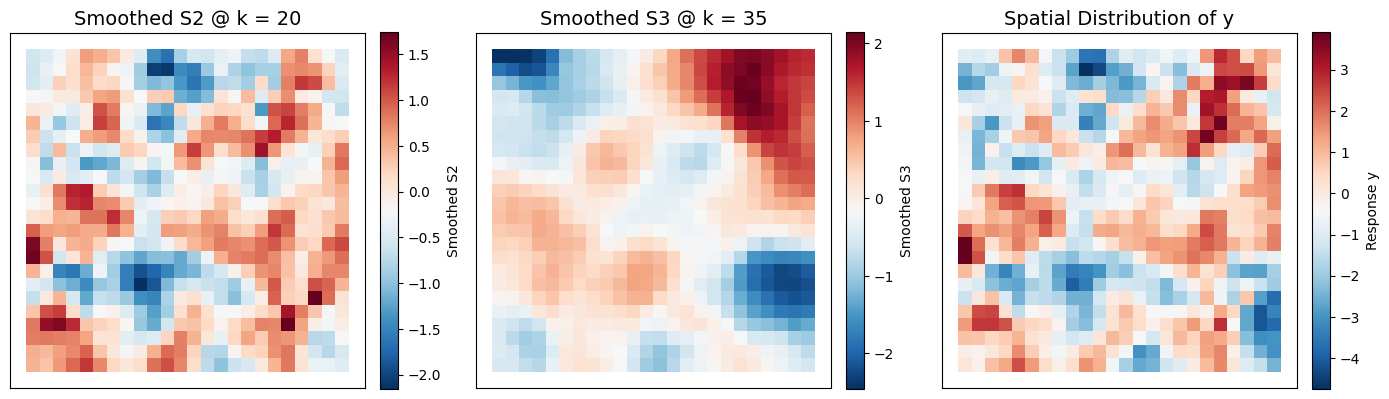

In [8]:
# Assign smoothed values and y to geodataframe
tracts_gdf24['sX2'] = smoothed_S2_to_S1
tracts_gdf24['sX3'] = smoothed_S3_to_S1
tracts_gdf24['y'] = y_orig

fig, ax = plt.subplots(1, 3, figsize=(14, 5))

# === Plot 1: smoothed X2 ===
norm_sx2 = mcolors.Normalize(vmin=tracts_gdf24["sX2"].min(), vmax=tracts_gdf24["sX2"].max())
tracts_gdf24.plot(
    column="sX2",
    cmap=plt.cm.RdBu_r,
    edgecolor="face",
    linewidth=0,
    legend=False,
    ax=ax[0]
)
sm0 = cm.ScalarMappable(norm=norm_sx2, cmap=plt.cm.RdBu_r)
sm0._A = []
cbar0 = fig.colorbar(sm0, ax=ax[0], fraction=0.046, pad=0.04)
cbar0.set_label("Smoothed S2")
ax[0].set_title(f"Smoothed S2 @ k = {k_S2}", fontsize=14)
ax[0].set_xticks([])
ax[0].set_yticks([])


# === Plot 2: smoothed X3 ===
norm_sx3 = mcolors.Normalize(vmin=tracts_gdf24["sX3"].min(), vmax=tracts_gdf24["sX3"].max())
tracts_gdf24.plot(
    column="sX3",
    cmap=plt.cm.RdBu_r,
    edgecolor="face",
    linewidth=0,
    legend=False,
    ax=ax[1]
)
sm1 = cm.ScalarMappable(norm=norm_sx3, cmap=plt.cm.RdBu_r)
sm1._A = []
cbar1 = fig.colorbar(sm1, ax=ax[1], fraction=0.046, pad=0.04)
cbar1.set_label("Smoothed S3")
ax[1].set_title(f"Smoothed S3 @ k = {k_S3}", fontsize=14)
ax[1].set_xticks([])
ax[1].set_yticks([])

# === Plot 2: y ===
norm_y = mcolors.Normalize(vmin=tracts_gdf24["y"].min(), vmax=tracts_gdf24["y"].max())
tracts_gdf24.plot(
    column="y",
    cmap=plt.cm.RdBu_r,
    edgecolor="face",
    linewidth=0,
    legend=False,
    ax=ax[2]
)
sm2 = cm.ScalarMappable(norm=norm_y, cmap=plt.cm.RdBu_r)
sm2._A = []
cbar2 = fig.colorbar(sm2, ax=ax[2], fraction=0.046, pad=0.04)
cbar2.set_label("Response y")
ax[2].set_title("Spatial Distribution of y", fontsize=14)
ax[2].set_xticks([])
ax[2].set_yticks([])
plt.tight_layout()
plt.show()

### Estimating an MGWR model

- Double aggregation of X2 points and then X3 points to the spatial support of y
  - Create a geodataframe
  - Spatially join the polygons in the target support
  - Aggregate by averaging within each polygon 

In [9]:
# Create GeoDataFrame for S2
agg_df['y'] = y_orig

df_S2 = gpd.GeoDataFrame({'S2': S2}, geometry=gpd.points_from_xy(loc2[:, 0], loc2[:, 1]))
S2_agg = gpd.sjoin(df_S2, agg_df, how="left", predicate="within")
S2_agg = S2_agg.groupby("tract_id")["S2"].mean().reset_index()

# Create GeoDataFrame for S3
df_S3 = gpd.GeoDataFrame({'S3': S3}, geometry=gpd.points_from_xy(loc3[:, 0], loc3[:, 1]))
S3_agg = gpd.sjoin(df_S3, agg_df, how="left", predicate="within")
S3_agg = S3_agg.groupby("tract_id")["S3"].mean().reset_index()

# Merge both aggregated covariates into a single DataFrame
same_sup_df = agg_df.merge(S2_agg, on='tract_id', how='left')
same_sup_df = same_sup_df.merge(S3_agg, on='tract_id', how='left')


In [10]:
same_sup_df.isna().sum()

tract_id     0
geometry     0
y            0
S2          23
S3          46
dtype: int64

In [11]:
same_sup_df.dropna(inplace=True)
same_sup_df.isna().sum()

tract_id    0
geometry    0
y           0
S2          0
S3          0
dtype: int64

In [12]:
g_X  = same_sup_df[['S2', 'S3']].values
g_y = same_sup_df['y'].values.reshape(-1, 1)
coords = np.array([[point.x, point.y] for point in same_sup_df['geometry'].centroid])

In [13]:
g_X.shape, g_y.shape

((509, 2), (509, 1))

In [14]:
mgwr_selector = Sel_BW(coords, g_y, g_X, multi=True, constant=False)
mgwr_bw = mgwr_selector.search(multi_bw_min=[2])
mgwr_results = MGWR(coords, g_y, g_X, mgwr_selector, constant=False).fit()

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Inference:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
mgwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                 509
Number of covariates:                                                     2

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            503.190
Log-likelihood:                                                    -719.318
AIC:                                                               1442.636
AICc:                                                              1444.684
BIC:                                                              -2656.661
R2:                                                                   0.609
Adj. R2:                                                              0.608

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

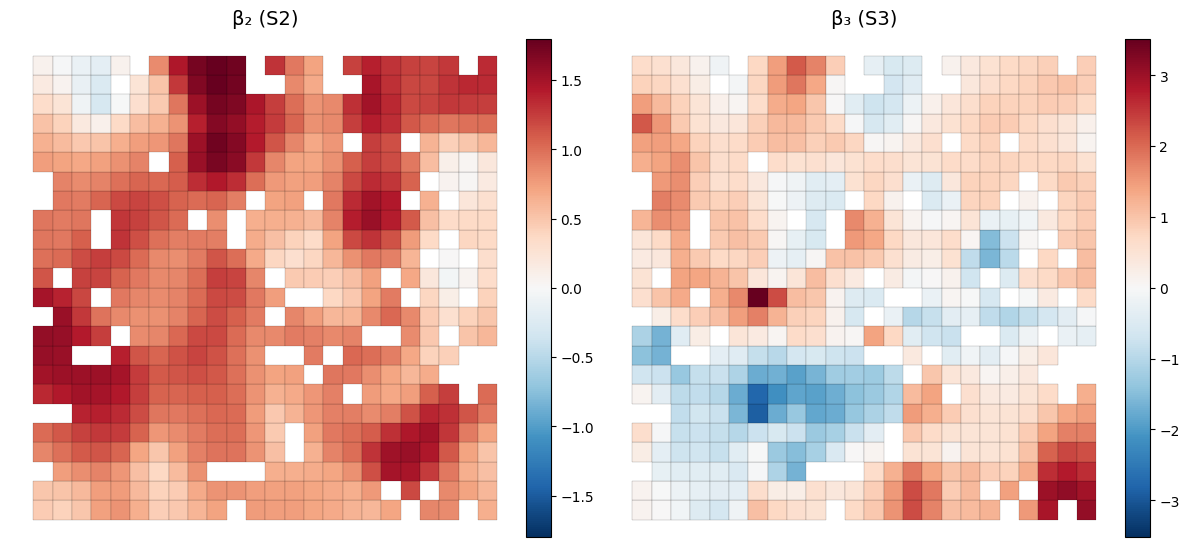

In [16]:

# Assign MGWR results to the same support DataFrame
same_sup_df['beta_S2'] = mgwr_results.params[:, 0]
same_sup_df['beta_S3'] = mgwr_results.params[:, 1]

# Set up 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Beta columns and titles to plot
beta_cols = ["beta_S2", "beta_S3"]
titles = ["β₂ (S2)", "β₃ (S3)"]

for i, col in enumerate(beta_cols):
    ax = axes[i]
    data = same_sup_df[col]

    # Determine appropriate colormap
    if data.min() < 0 and data.max() > 0:
        cmap = plt.cm.RdBu_r
        max_abs = max(abs(data.min()), abs(data.max()))
        vmin, vmax = -max_abs, max_abs
    else:
        cmap = plt.cm.Reds
        vmin, vmax = data.min(), data.max()

    # Plot the surface
    same_sup_df.plot(column=col, cmap=cmap, linewidth=0.1, edgecolor='k',
                     ax=ax, vmin=vmin, vmax=vmax)
    ax.set_title(titles[i], fontsize=14)
    ax.axis('off')

    # Add colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.046, pad=0.01)

plt.tight_layout()
plt.show()


In [17]:
mgwr_params = mgwr_results.params
mgwr_y_pred = mgwr_results.predy
mgwr_aicc = mgwr_results.aicc
mgwr_r2 = mgwr_results.R2

print(mgwr_results.aicc), print(mgwr_results.R2);

1209.1458296457704
0.8854775126058273


In [18]:
## calculating the standardized root mean squared error
y_true = same_sup_df['y'].values.reshape(-1,1)
rmse  = np.sqrt(np.mean((y_true - mgwr_y_pred)**2))
std_dev = np.std(y_true)
srmse = rmse / std_dev
srmse, rmse

(np.float64(0.33841171285015037), np.float64(0.5382274757002682))

### Multivariate GLASS

In [19]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from sklearn.metrics import r2_score, mean_squared_error

def compute_aicc(y_true, y_pred, tr_S, n_params):
    n = len(y_true)
    resid = y_true - y_pred
    sigma2 = np.sum(resid ** 2) / (n - tr_S)
    aicc = (
        n * np.log(sigma2)
        + n * ((n + tr_S) / (n - 2 - tr_S))
    )
    return aicc

def smooth_covariate(source_vals, loc_target, loc_source, K):
    smoothed = np.zeros(len(loc_target))
    nbrs = NearestNeighbors(n_neighbors=K).fit(loc_source)
    dists, indices = nbrs.kneighbors(loc_target)
    for i in range(len(loc_target)):
        bw = dists[i].max()
        weights = np.exp(-0.5 * (dists[i] / bw) ** 2)
        weights /= weights.sum()
        smoothed[i] = np.dot(source_vals[indices[i]], weights)
    return smoothed.reshape(-1, 1)

def multivariate_glass_nested_backfitting(
    loc_target, y, covariates, support_map, K_grid, loc_sources=None,
    max_iter=10, tol=1e-4
):
    n, p = len(y), len(covariates)
    y = y.reshape(-1, 1)
    X_best = [None] * p
    K_best = [None] * p
    bws_best = [None] * p
    final_params = np.zeros((n, p))

    for j in range(p):
        print(f"\n=== Optimizing K for Variable {j+1} ===")
        best_aicc = np.inf
        best_K = None
        best_Xj = None
        best_bws = None
        best_params = None
        best_predy = None
        best_total_trace = None
        results_per_K = []  # ← Stores metrics per K

        for K in K_grid if support_map[j] == 'source' else [None]:
            X_current = []
            for k in range(p):
                if k == j:
                    if support_map[k] == 'target':
                        xk = covariates[k].reshape(-1, 1)
                    else:
                        xk = smooth_covariate(covariates[k], loc_target, loc_sources[k], K)
                else:
                    if X_best[k] is None:
                        if support_map[k] == 'target':
                            xk = covariates[k].reshape(-1, 1)
                        else:
                            xk = smooth_covariate(covariates[k], loc_target, loc_sources[k], K_grid[0])
                    else:
                        xk = X_best[k]
                X_current.append(xk)
            X_full = np.hstack(X_current)

            params = np.zeros((n, p))
            bws = [None] * p
            predy = np.zeros((n, 1))
            predy_old = np.zeros_like(predy)
            total_trace = 0.0  # ← Total model influence

            for it in range(max_iter):
                for m in range(p):
                    X_m = X_full[:, [m]]
                    X_other = np.delete(X_full, m, axis=1)
                    beta_other = np.delete(params, m, axis=1)
                    y_m = y - (X_other * beta_other).sum(axis=1, keepdims=True)

                    bw = Sel_BW(loc_target, y_m, X_m, constant=False).search(bw_min=2)
                    gwr = GWR(loc_target, y_m, X_m, bw, constant=False)
                    res = gwr.fit()
                    params[:, m] = res.params.flatten()
                    bws[m] = bw

                predy = (X_full * params).sum(axis=1, keepdims=True)
                if it > 0 and np.linalg.norm(predy - predy_old) < tol:
                    break
                predy_old = predy.copy()

            # Recalculate total trace from all final variable fits
            total_trace = 0.0
            for m in range(p):
                X_m = X_full[:, [m]]
                X_other = np.delete(X_full, m, axis=1)
                beta_other = np.delete(params, m, axis=1)
                y_m = y - (X_other * beta_other).sum(axis=1, keepdims=True)
                bw = bws[m]
                gwr = GWR(loc_target, y_m, X_m, bw, constant=False)
                res = gwr.fit()
                total_trace += res.influ.trace()

            aicc = compute_aicc(y, predy, total_trace, p)
            r2 = r2_score(y, predy)
            srmse = np.sqrt(mean_squared_error(y, predy)) / np.std(y)

            print(f"K = {K} | AICc = {aicc:.4f} | R² = {r2:.4f} | SRMSE = {srmse:.4f}")
            results_per_K.append({
                'K': K,
                'aicc': aicc,
                'r2': r2,
                'srmse': srmse,
                'bws': bws.copy()
            })

            if aicc < best_aicc:
                best_aicc = aicc
                best_K = K
                best_Xj = X_current[j]
                best_bws = bws
                best_params = params.copy()
                best_predy = predy.copy()
                best_total_trace = total_trace

        K_best[j] = best_K
        X_best[j] = best_Xj
        bws_best = best_bws
        final_params = best_params

    return {
        'K_best': K_best,
        'bws': bws_best,
        'params': final_params,
        # 'predy': best_predy,
        'r2': r2_score(y, best_predy),
        'srmse': np.sqrt(mean_squared_error(y, best_predy)) / np.std(y),
        'aicc': compute_aicc(y, best_predy, best_total_trace, p),
        'results_per_K': results_per_K  # dataframe for plotting 
    }


In [20]:
best_results = multivariate_glass_nested_backfitting(
    loc1, y_orig, [S2, S3], ['source', 'source'], list(range(5, 50, 5)),
    max_iter=10, tol=1e-5, loc_sources=[loc2, loc3]
)


=== Optimizing K for Variable 1 ===
K = 5 | AICc = -109.4875 | R² = 0.8762 | SRMSE = 0.3518
K = 10 | AICc = -277.8381 | R² = 0.9076 | SRMSE = 0.3040
K = 15 | AICc = -619.4581 | R² = 0.9489 | SRMSE = 0.2260
K = 20 | AICc = -866.1749 | R² = 0.9667 | SRMSE = 0.1824
K = 25 | AICc = -823.4677 | R² = 0.9642 | SRMSE = 0.1893
K = 30 | AICc = -720.9821 | R² = 0.9572 | SRMSE = 0.2069
K = 35 | AICc = -611.4224 | R² = 0.9482 | SRMSE = 0.2275
K = 40 | AICc = -457.7536 | R² = 0.9324 | SRMSE = 0.2600
K = 45 | AICc = -379.0502 | R² = 0.9225 | SRMSE = 0.2784

=== Optimizing K for Variable 2 ===
K = 5 | AICc = -866.1749 | R² = 0.9667 | SRMSE = 0.1824
K = 10 | AICc = -911.6871 | R² = 0.9693 | SRMSE = 0.1753
K = 15 | AICc = -916.7245 | R² = 0.9695 | SRMSE = 0.1746
K = 20 | AICc = -924.9542 | R² = 0.9700 | SRMSE = 0.1733
K = 25 | AICc = -943.0669 | R² = 0.9709 | SRMSE = 0.1706
K = 30 | AICc = -954.4399 | R² = 0.9715 | SRMSE = 0.1689
K = 35 | AICc = -973.5911 | R² = 0.9724 | SRMSE = 0.1661
K = 40 | AICc = 

In [21]:
best_results#['params'][:,0]

{'K_best': [20, 35],
 'bws': [np.float64(575.0), np.float64(10.0)],
 'params': array([[1.95340292, 1.51354196],
        [1.95322424, 1.66789891],
        [1.95303239, 1.17409881],
        ...,
        [1.95247694, 0.70046182],
        [1.95229119, 0.90878978],
        [1.95212134, 0.88262685]], shape=(576, 2)),
 'r2': 0.9724095273221626,
 'srmse': np.float64(0.16610380091327642),
 'aicc': np.float64(-973.5910734961536),
 'results_per_K': [{'K': 5,
   'aicc': np.float64(-866.1749464523275),
   'r2': 0.9667221815944749,
   'srmse': np.float64(0.18242208858996517),
   'bws': [np.float64(286.0), np.float64(10.0)]},
  {'K': 10,
   'aicc': np.float64(-911.6870924342717),
   'r2': 0.9692537391258517,
   'srmse': np.float64(0.17534611736262753),
   'bws': [np.float64(286.0), np.float64(10.0)]},
  {'K': 15,
   'aicc': np.float64(-916.7244613962102),
   'r2': 0.9695225186084536,
   'srmse': np.float64(0.17457800947297553),
   'bws': [np.float64(313.0), np.float64(10.0)]},
  {'K': 20,
   'aicc': 

In [22]:
same_sup_glass = agg_df.copy()

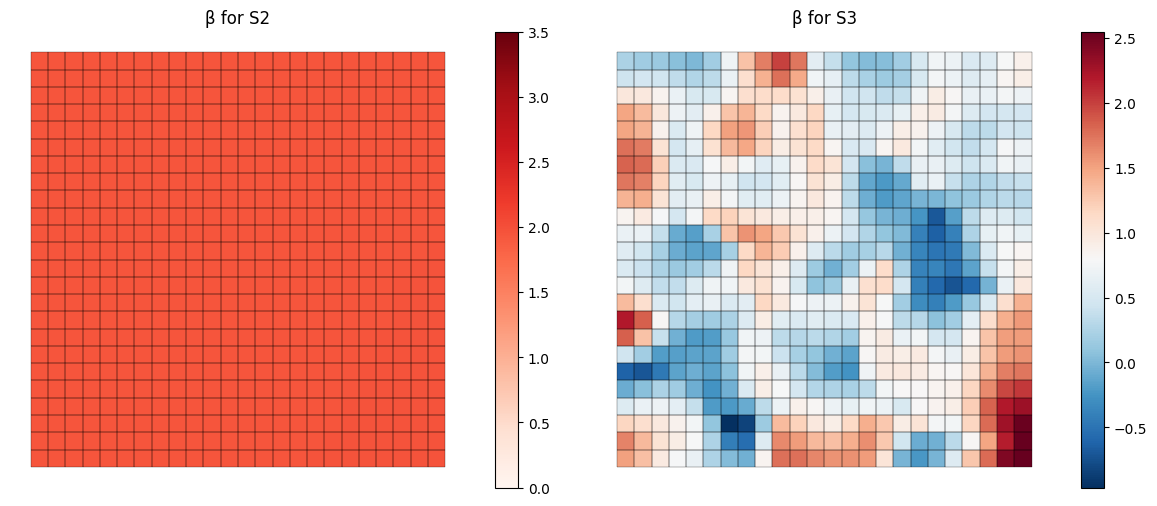

In [23]:

# Assign MGWR results to the same support DataFrame
same_sup_glass['beta_S2'] = best_results['params'][:, 0]
same_sup_glass['beta_S3'] = best_results['params'][:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# β for S2
tracts_gdf24.boundary.plot(ax=axes[0], edgecolor='black', linewidth=0.2)  # base layer
same_sup_glass.plot(
    column='beta_S2',
    cmap='Reds',
    legend=True,
    ax=axes[0],
    vmin=0, 
    vmax=3.5
)
axes[0].set_title("β for S2")
axes[0].axis('off')

# β for S3
tracts_gdf24.boundary.plot(ax=axes[1], facecolor='none', edgecolor='black', linewidth=0.2)
same_sup_glass.plot(
    column='beta_S3',
    cmap='RdBu_r',
    legend=True,
    ax=axes[1]
)
axes[1].set_title("β for S3")
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [24]:
same_sup_glass['beta_S3'].max()

np.float64(2.5488544329394993)

In [25]:
best_results['aicc']

np.float64(-973.5910734961536)

In [26]:
plot = pd.DataFrame(best_results['results_per_K'])

<Axes: xlabel='K'>

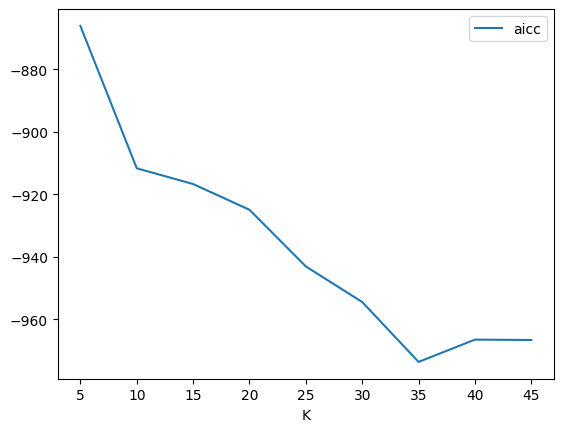

In [27]:
plot.plot(x='K', y='aicc')